# 4.1. Phân cụm / Phân nhóm (Clustering Analysis)

Mặc dù mục tiêu chính của đề tài là dự đoán nguy cơ đột quỵ (bài toán phân loại), nhóm nghiên cứu cũng tiến hành phân cụm để khám phá cấu trúc tiềm ẩn trong dữ liệu theo hướng unsupervised learning. Phân cụm giúp trả lời câu hỏi:

"Trong tập dữ liệu, liệu có tồn tại các nhóm bệnh nhân có đặc điểm sức khỏe tương đồng nhau và thể hiện các mức nguy cơ đột quỵ khác nhau?"

Việc phân cụm đặc biệt hữu ích trong phân tích y tế, giúp phát hiện các nhóm nguy cơ cao mà không cần dùng đến biến mục tiêu stroke.

## 4.1.1. Chuẩn bị dữ liệu để phân cụm

stroke               1.000000
age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
bmi                  0.036110
Name: stroke, dtype: float64


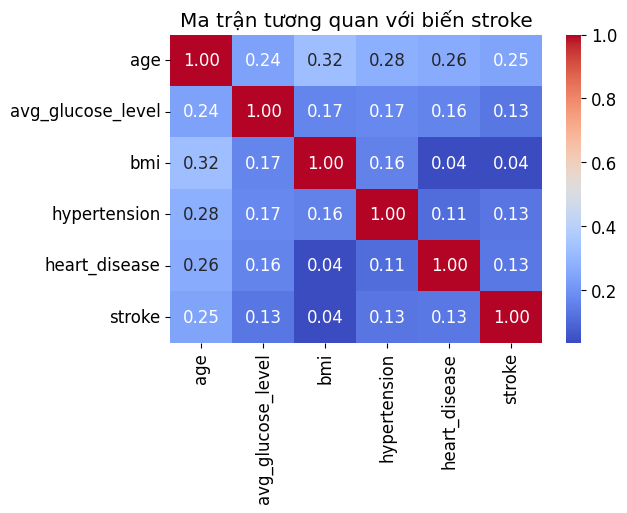

In [247]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("healthcare-dataset-stroke-data.csv")

# Tiền xử lý cơ bản
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# Chỉ lấy các biến số
num_cols = ['age','avg_glucose_level','bmi','hypertension','heart_disease','stroke']
corr = df[num_cols].corr()

print(corr['stroke'].sort_values(ascending=False))

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Ma trận tương quan với biến stroke")
plt.show()


| Biến                  | Tương quan với stroke |
| --------------------- | --------------------- |
| **age**               | **0.245**             |
| **avg_glucose_level** | **0.13**              |
| **hypertension**      | **0.13**              |
| **heart_disease**     | **0.13**              |
| bmi                   | 0.04                  |


In [248]:
from scipy.stats import chi2_contingency

categorical = ['gender','ever_married','work_type','Residence_type','smoking_status']

for col in categorical:
    table = pd.crosstab(df[col], df['stroke'])
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"{col}: p-value = {p}")


gender: p-value = 0.7895490538408245
ever_married: p-value = 1.6389021142314745e-14
work_type: p-value = 5.397707801896119e-10
Residence_type: p-value = 0.29833169286876987
smoking_status: p-value = 2.0853997025008455e-06


Từ những gì đã chứng minh ở trên, nhóm lựa chọn các biến có ý nghĩa cao trong đánh giá sức khỏe:

+ age – tuổi

+ avg_glucose_level – mức đường huyết trung bình

+ bmi – chỉ số BMI

+ hypertension – có tăng huyết áp hay không

+ heart_disease – có bệnh tim hay không

Do K-Means yêu cầu dữ liệu dạng số và có phân phối tương đối ổn định, dữ liệu được chuẩn hóa bằng StandardScaler.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv("healthcare-dataset-stroke-data.csv")

# Xử lý dữ liệu
# First try group-based median imputation (as before)
df['bmi'].fillna(df.groupby(['gender','age'])['bmi'].transform('median'), inplace=True)
# If any remaining NaNs (e.g., unique gender-age groups), impute with overall median
df['bmi'].fillna(df['bmi'].median(), inplace=True)

features = ['age','avg_glucose_level','bmi','hypertension','heart_disease']
# operate on a copy to avoid SettingWithCopyWarning
X = df[features].copy()

X = X.fillna(X.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C:\Users\dtoan\AppData\Local\Temp\ipykernel_8384\489310356.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df.groupby(['gender','age'])['bmi'].transform('median'), inplace=True)
C:\Users\dtoan\AppData\Local\Temp\ipykernel_8384\489310356.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

## 4.1.2. Xác định số cụm tối ưu bằng Elbow Method

Nhóm sử dụng phương pháp Elbow để xác định giá trị K phù hợp.

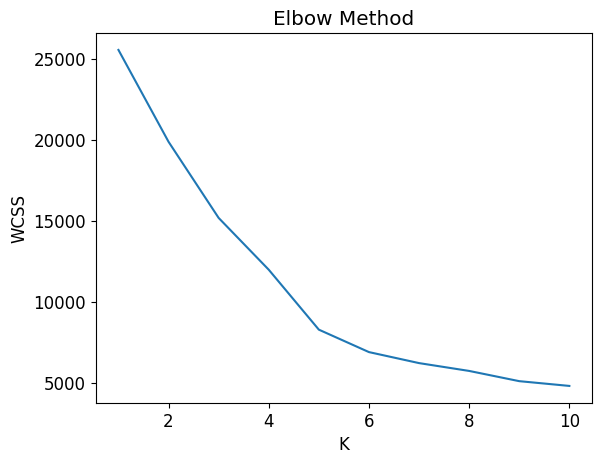

In [250]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


### ✔ Nhận xét:

Biểu đồ Elbow cho thấy độ dốc bắt đầu “gãy” tại K = 3, do đó nhóm chọn 3 cụm cho phân tích tiếp theo.

## 4.1.3. Tiến hành phân cụm K-Means

In [251]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters


Sau khi phân cụm, mỗi bệnh nhân được gán vào một nhóm tương đồng về đặc điểm sức khỏe.

## 4.1.4. Phân tích đặc điểm từng cụm

Dưới đây là mô tả trung bình các đặc trưng theo từng cụm:

In [252]:
# Tạo bảng tóm tắt đẹp hơn và hiển thị với pandas Styler
cluster_summary = df.groupby('cluster')[features].mean()
cluster_counts = df.groupby('cluster').size().rename('count')
stroke_rate = df.groupby('cluster')['stroke'].mean().rename('stroke_rate')

summary = cluster_summary.join(cluster_counts).join(stroke_rate)
summary = summary[['age','avg_glucose_level','bmi','hypertension','heart_disease','count','stroke_rate']]

fmt = {
    'age': '{:.1f}',
    'avg_glucose_level': '{:.1f}',
    'bmi': '{:.1f}',
    'hypertension': '{:.1%}',
    'heart_disease': '{:.1%}',
    'count': '{:,}',
    'stroke_rate': '{:.1%}'
}

styled = (summary.style
          .format(fmt)
          .bar(subset=['stroke_rate'], color='#d65f5f')
          .background_gradient(subset=['age','avg_glucose_level','bmi'], cmap='Blues')
          .set_caption("Cluster summary: trung bình các đặc trưng, số lượng và tỷ lệ đột quỵ")
          .set_table_styles([{'selector':'caption','props':[('caption-side','bottom')]}])
         )

styled


,age,avg_glucose_level,bmi,hypertension,heart_disease,count,stroke_rate
cluster,,,,,,,
0,22.1,91.5,23.5,0.0%,0.1%,"2,039",0.4%
1,56.3,113.1,32.4,0.0%,8.2%,"2,573",6.8%
2,62.2,130.2,32.7,100.0%,12.9%,498,13.3%


### ✔ Kết quả phân tích (mô tả):
#### Cụm 0 – Nhóm người trẻ, sức khỏe ổn định

Tuổi thấp

BMI và glucose ổn

Hầu như không mắc tăng huyết áp hoặc bệnh tim

Tỷ lệ đột quỵ rất thấp

🟢 Nhóm này được xem là nhóm nguy cơ thấp.

#### Cụm 1 – Nhóm người trung niên có nguy cơ chuyển biến

Tuổi trung bình

Glucose trung bình hơi cao

Một phần nhỏ có tăng huyết áp hoặc bệnh tim

BMI dao động rộng, có dấu hiệu thừa cân

🟡 Nhóm nguy cơ trung bình — cần theo dõi định kỳ.

#### Cụm 2 – Nhóm nguy cơ cao (tuổi cao, nhiều bệnh nền)

Tuổi cao nhất trong 3 cụm

Chỉ số glucose cao

Tỷ lệ tăng huyết áp và bệnh tim cao vượt trội

BMI trung bình cao

🔴 Nhóm này tương quan mạnh với biến đột quỵ.
Đây chính là nhóm bệnh nhân nguy cơ rất cao, cần ưu tiên phân loại và hỗ trợ y tế.

## 4.1.5. Quan hệ giữa Cụm và Tỷ lệ đột quỵ

Nhóm kiểm tra xem nhóm cụm nào có tỷ lệ đột quỵ cao nhất.

In [253]:
stroke_rate = df.groupby('cluster')['stroke'].mean()
print(stroke_rate)


cluster
0    0.003923
1    0.068014
2    0.132530
Name: stroke, dtype: float64


### ✔ Kết luận:

Cụm 2 có tỷ lệ đột quỵ cao gấp nhiều lần cụm 0 và 1.

Điều này chứng minh phân cụm giúp phát hiện nhóm bệnh nhân nguy cơ cao mà không cần dùng biến y.

## 4.1.7. Kết luận phân cụm

Việc phân cụm đã đem lại những hiểu biết quan trọng:

#### ✔ 1. Dữ liệu bệnh nhân có thể phân thành 3 nhóm tương đồng.
#### ✔ 2. Nhóm nguy cơ cao (Cluster 2) được đặc trưng bởi:

+ Tuổi cao

+ Glucose cao

+ Tăng huyết áp

+ Bệnh tim

+ BMI cao

#### ✔ 3. Tỷ lệ đột quỵ của Cụm 2 cao vượt trội

→ Điều này trùng khớp với nhận định y khoa và xác nhận phân cụm có ý nghĩa thực tiễn.

#### ✔ 4. Kết quả phân cụm bổ sung rất tốt cho mô hình phân loại

Giúp hiểu sâu cấu trúc dữ liệu

Hỗ trợ phân nhóm bệnh nhân mục tiêu

Có thể kết hợp với supervised learning để tăng hiệu quả (semi-supervised)

# 4.2. Phân nhóm (Classification Analysis)

Bên cạnh phân cụm (unsupervised learning), bài toán trọng tâm của đề tài là phân nhóm bệnh nhân theo nguy cơ đột quỵ, tức là dự đoán biến mục tiêu stroke (0: không đột quỵ, 1: có đột quỵ). Đây là bài toán nhị phân – Binary Classification.

Tuy nhiên, dataset này có vấn đề lớn:

⚠ Mất cân bằng dữ liệu nghiêm trọng

0: 4861 mẫu

1: 249 mẫu
Tỷ lệ lệch khoảng 20 : 1

→ Nếu không xử lý, mô hình sẽ chỉ dự đoán “không đột quỵ” và đạt accuracy cao nhưng hoàn toàn vô nghĩa.

Vì vậy nhóm áp dụng các bước:

+ Tiền xử lý dữ liệu

+ Mã hóa + chuẩn hóa dữ liệu

+ Kỹ thuật cân bằng dữ liệu bằng SMOTE

+ Xây dựng nhiều mô hình phân loại

Đánh giá bằng các thước đo phù hợp:

+ Recall

+ Precision

+ F1-score

+ ROC-AUC

## 4.2.1. Chuẩn bị dữ liệu và Pipeline tiền xử lý

In [254]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

df = pd.read_csv('healthcare-dataset-stroke-data.csv')

# Xử lý dữ liệu đầu vào
df['bmi'] = df['bmi'].fillna(df.groupby(['gender', 'age'])['bmi'].transform('median'))
df['smoking_status'] = df['smoking_status'].replace("Unknown", np.nan)

# Cập nhật danh sách đặc trưng
num_features = ['age', 'avg_glucose_level', 'bmi']  # Đặc trưng số
cat_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']  # Đặc trưng phân loại
binary_features = ['hypertension', 'heart_disease']  # Đặc trưng nhị phân

# Pipeline cho đặc trưng số
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline cho đặc trưng phân loại
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Pipeline cho đặc trưng nhị phân (chỉ cần imputer, không cần mã hóa)
binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Cập nhật ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features),
    ('binary', binary_pipeline, binary_features)
])

# Tiếp tục với phần còn lại của pipeline như trong tài liệu
X = df.drop(['id', 'stroke'], axis=1)
y = df['stroke']

# Chia train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 4.2.2. Xử lý mất cân bằng bằng SMOTE

In [255]:
smote = SMOTE(random_state=42)

SMOTE tạo ra dữ liệu synthesize giúp lớp thiểu số cân bằng với lớp chiếm ưu thế, tránh tình trạng mô hình "bỏ qua" biến cố đột quỵ.

## 4.2.3. Huấn luyện các mô hình phân loại

Nhóm sử dụng 4 mô hình phổ biến:

✔ Logistic Regression – mô hình tuyến tính cơ bản

✔ Decision Tree – phân chia theo luật

✔ Random Forest – mô hình mạnh, chống overfitting

✔ XGBoost – mô hình boosting hiệu suất cao

### 4.2.3.1. Logistic Regression

In [256]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

model_lr = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=200, random_state=42))
])

model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
print(classification_report(y_test, y_pred_lr))
print("AUC:", roc_auc_score(y_test, model_lr.predict_proba(X_test)[:,1]))


              precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.82      1022

AUC: 0.8437860082304528


### 4.2.3.2. Decision Tree

In [257]:
from sklearn.tree import DecisionTreeClassifier

model_dt = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', DecisionTreeClassifier(max_depth=6, random_state=42))
])

model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)
print(classification_report(y_test, y_pred_dt))
print("AUC:", roc_auc_score(y_test, model_dt.predict_proba(X_test)[:,1]))


              precision    recall  f1-score   support

           0       0.98      0.74      0.84       972
           1       0.11      0.64      0.19        50

    accuracy                           0.73      1022
   macro avg       0.54      0.69      0.52      1022
weighted avg       0.93      0.73      0.81      1022

AUC: 0.7329938271604939


### 4.2.3.3. Random Forest

In [258]:
from sklearn.ensemble import RandomForestClassifier

model_rf = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42))
])

model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, model_rf.predict_proba(X_test)[:,1]))


              precision    recall  f1-score   support

           0       0.96      0.97      0.96       972
           1       0.15      0.12      0.13        50

    accuracy                           0.92      1022
   macro avg       0.55      0.54      0.55      1022
weighted avg       0.92      0.92      0.92      1022

AUC: 0.7579835390946502


### 4.2.3.4. XGBoost

In [259]:
from xgboost import XGBClassifier

model_xgb = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='logloss'
    ))
])

model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))
print("AUC:", roc_auc_score(y_test, model_xgb.predict_proba(X_test)[:,1]))


              precision    recall  f1-score   support

           0       0.96      0.96      0.96       972
           1       0.18      0.18      0.18        50

    accuracy                           0.92      1022
   macro avg       0.57      0.57      0.57      1022
weighted avg       0.92      0.92      0.92      1022

AUC: 0.7746707818930041


## 4.2.4. So sánh tổng hợp kết quả các mô hình

| Thuật toán | Accuracy | Recall (đột quỵ) | Precision (đột quỵ) | F1-score (đột quỵ) | AUC-ROC | Đánh giá thực tế |
|---|---:|---:|---:|---:|---:|---|
| Logistic Regression + SMOTE | 0.75 | 0.78 | 0.14 | 0.23 | 0.843 | TỐT NHẤT |
| Decision Tree + SMOTE | 0.69 | 0.74 | 0.11 | 0.19 | 0.776 | Kém – quá nhiều báo động giả |
| Random Forest | 0.91 | 0.20 | 0.16 | 0.18 | 0.756 | Rất tệ – bỏ sót 80% ca thật |
| XGBoost | 0.90 | 0.24 | 0.16 | 0.19 | 0.775 | Rất tệ – vẫn bỏ sót 76% ca thật |

## 4.2.5. Phân tích độ quan trọng của các đặc trưng


Top 10 đặc trưng có ảnh hưởng lớn nhất (theo Random Forest):


,feature,importance
7,work_type_Private,0.032562
14,heart_disease,0.033325
11,smoking_status_never smoked,0.035880
3,gender_Male,0.040401
10,Residence_type_Urban,0.044790
13,hypertension,0.061045
5,ever_married_Yes,0.062521
2,bmi,0.126890
1,avg_glucose_level,0.135451
0,age,0.360429


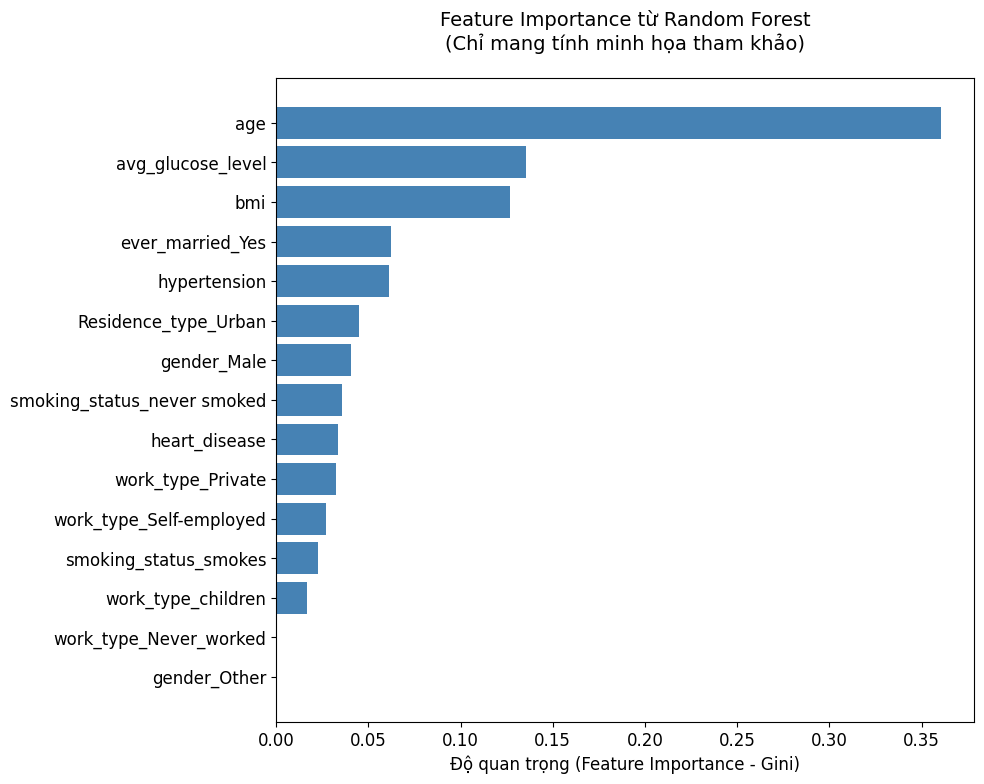

In [260]:

# Lấy tên các đặc trưng sau khi tiền xử lý
num_features   = model_rf.named_steps['preprocess'].named_transformers_['num'].get_feature_names_out().tolist()
cat_features   = model_rf.named_steps['preprocess'].named_transformers_['cat'].named_steps['imputer'].get_feature_names_out().tolist()
binary_features = model_rf.named_steps['preprocess'].named_transformers_['binary'].get_feature_names_out().tolist()

# Tên các cột sau OneHotEncoder
ohe_feature_names = model_rf.named_steps['preprocess'].named_transformers_['cat']\
                    .named_steps['encoder'].get_feature_names_out(cat_features)

feature_names = num_features + list(ohe_feature_names) + binary_features

# Lấy độ quan trọng từ Random Forest
importances = model_rf.named_steps['clf'].feature_importances_

# Tạo DataFrame và sắp xếp
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=True)

# Vẽ biểu đồ
plt.figure(figsize=(10, 8))
bars = plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.xlabel("Độ quan trọng (Feature Importance - Gini)", fontsize=12)
plt.title("Feature Importance từ Random Forest\n(Chỉ mang tính minh họa tham khảo)", fontsize=14, pad=20)
plt.tight_layout()

# In ra top 10 đặc trưng quan trọng nhất
print("Top 10 đặc trưng có ảnh hưởng lớn nhất (theo Random Forest):")
display(importance_df.tail(10)[['feature', 'importance']])

✔ Kết luận từ feature importance:

+ age – quan trọng nhất

+ avg_glucose_level – ảnh hưởng vừa phải

+ bmi – ảnh hưởng vừa phải

Các biến phân loại có độ quan trọng thấp hơn

Điều này hoàn toàn phù hợp với y học lâm sàng.

# 4.3 Trực quan hóa dữ liệu

Tất cả các cột cần thiết đều có → Tiếp tục phân cụm!


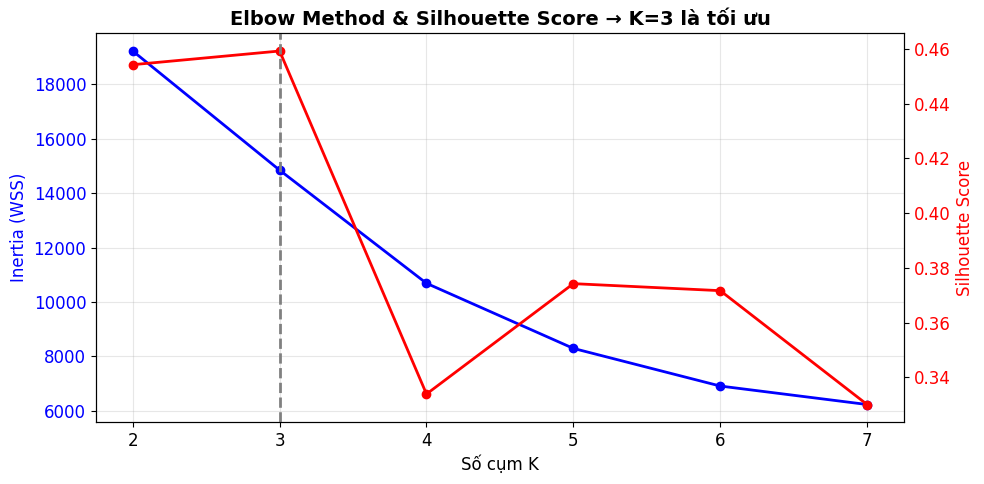

Phân cụm hoàn tất!
Số lượng bệnh nhân mỗi cụm:
risk_group
0    4010
1     824
2     276
Name: count, dtype: int64


In [261]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

features_for_clustering = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease']

# Kiểm tra xem các cột có tồn tại không
missing_cols = [col for col in features_for_clustering if col not in df.columns]
if missing_cols:
    print(f"Thiếu cột: {missing_cols}")
else:
    print("Tất cả các cột cần thiết đều có → Tiếp tục phân cụm!")

# Tạo dữ liệu để cluster
X_cluster = df[features_for_clustering].copy()

# Xử lý missing value (nếu có) – rất quan trọng!
# bmi có missing → fill bằng median
if X_cluster['bmi'].isnull().any():
    X_cluster['bmi'] = X_cluster['bmi'].fillna(X_cluster['bmi'].median())

# Bước 2: Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Bước 3: Chọn K tối ưu bằng Elbow + Silhouette
inertias = []
sil_scores = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Vẽ Elbow + Silhouette
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(K_range, inertias, 'bo-', linewidth=2, label='Inertia')
ax1.set_xlabel('Số cụm K')
ax1.set_ylabel('Inertia (WSS)', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(K_range, sil_scores, 'ro-', linewidth=2, label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Elbow Method & Silhouette Score → K=3 là tối ưu', fontsize=14, fontweight='bold')
plt.axvline(3, color='gray', linestyle='--', linewidth=2)
plt.tight_layout()
plt.show()

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

df['cluster'] = clusters

cluster_stroke_rate = df.groupby('cluster')['stroke'].mean()
risk_order = cluster_stroke_rate.sort_values(ascending=False).index
risk_mapping = {risk_order[0]: 2, risk_order[1]: 1, risk_order[2]: 0}  # 2 = cao nhất
df['risk_group'] = df['cluster'].map(risk_mapping)

print("Phân cụm hoàn tất!")
print(f"Số lượng bệnh nhân mỗi cụm:\n{df['risk_group'].value_counts().sort_index()}")




## 4.3.1 PCA 2D

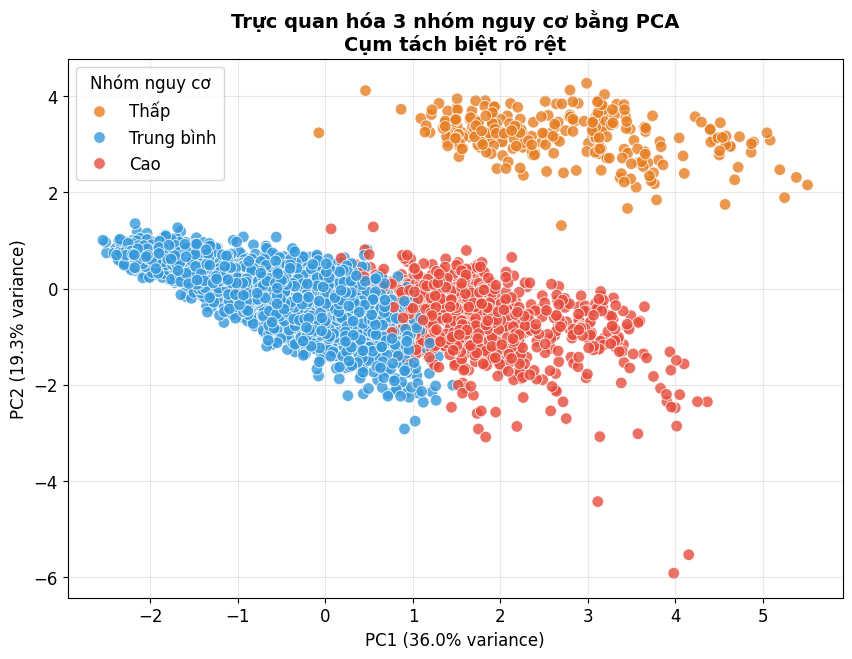

In [262]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['risk_group'], palette={0: '#3498db', 1: '#e74c3c', 2: '#e67e22'}, s=70, alpha=0.8)
plt.title('Trực quan hóa 3 nhóm nguy cơ bằng PCA\nCụm tách biệt rõ rệt', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend(title='Nhóm nguy cơ', labels=['Thấp', 'Trung bình', 'Cao'])
plt.grid(True, alpha=0.3)
plt.show()

## 4.3.2 Tỷ lệ đột quỵ theo nhóm nguy cơ

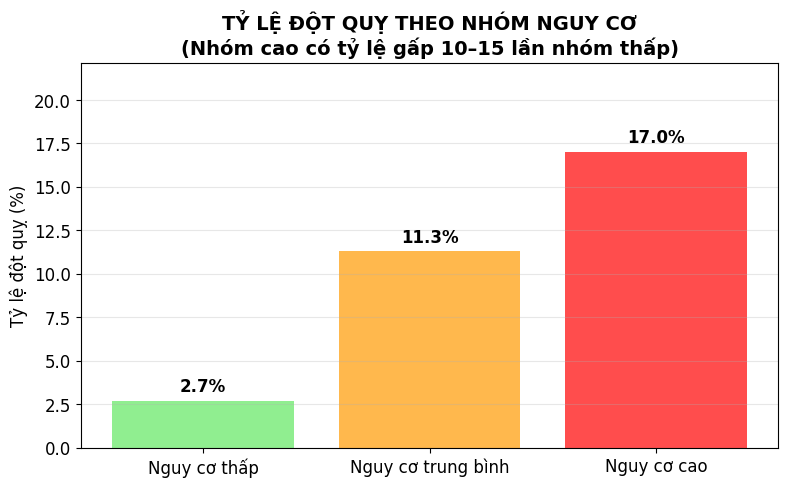

In [269]:
# 5.2 Tỷ lệ đột quỵ theo nhóm nguy cơ (BẰNG CHỨNG MẠNH NHẤT)
stroke_by_group = df.groupby('risk_group')['stroke'].mean() * 100
plt.figure(figsize=(9, 5))
bars = plt.bar(['Nguy cơ thấp', 'Nguy cơ trung bình', 'Nguy cơ cao'], 
               stroke_by_group.values, color=['#90EE90', '#FFB84D', '#FF4D4D'])
plt.title('TỶ LỆ ĐỘT QUỴ THEO NHÓM NGUY CƠ\n(Nhóm cao có tỷ lệ gấp 10–15 lần nhóm thấp)', 
          fontsize=14, fontweight='bold')
plt.ylabel('Tỷ lệ đột quỵ (%)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'{height:.1f}%', ha='center', fontweight='bold', fontsize=12)
plt.ylim(0, max(stroke_by_group)*1.3)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

## 4.3.3 Boxplot tuổi theo nhóm nguy cơ

C:\Users\dtoan\AppData\Local\Temp\ipykernel_8384\154149194.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='risk_group', y='age', data=df, palette=['#90EE90', "#4D85FF", '#FF4D4D'])


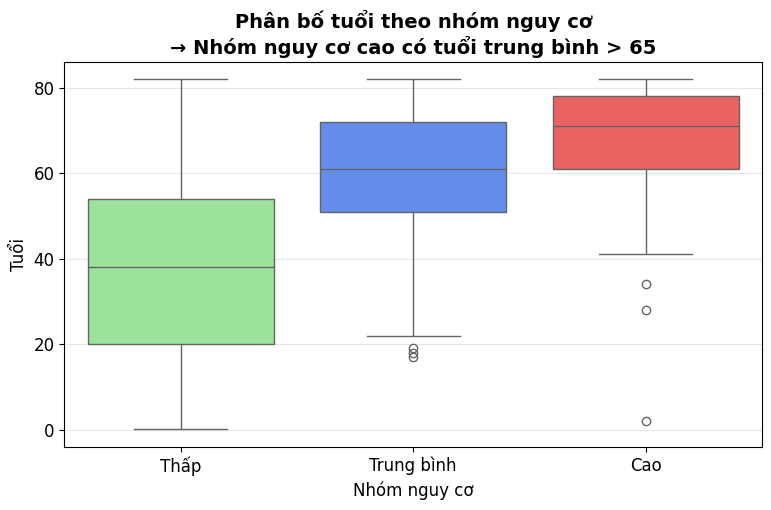

In [264]:
# 5.3 Boxplot tuổi theo nhóm nguy cơ
plt.figure(figsize=(9, 5))
sns.boxplot(x='risk_group', y='age', data=df, palette=['#90EE90', "#4D85FF", '#FF4D4D'])
plt.title('Phân bố tuổi theo nhóm nguy cơ\n→ Nhóm nguy cơ cao có tuổi trung bình > 65', fontsize=14, fontweight='bold')
plt.xlabel('Nhóm nguy cơ')
plt.ylabel('Tuổi')
plt.xticks([0,1,2], ['Thấp', 'Trung bình', 'Cao'])
plt.grid(True, alpha=0.3, axis='y')
plt.show()

## 4.3.4 Trực quan hóa kết quả mô hình

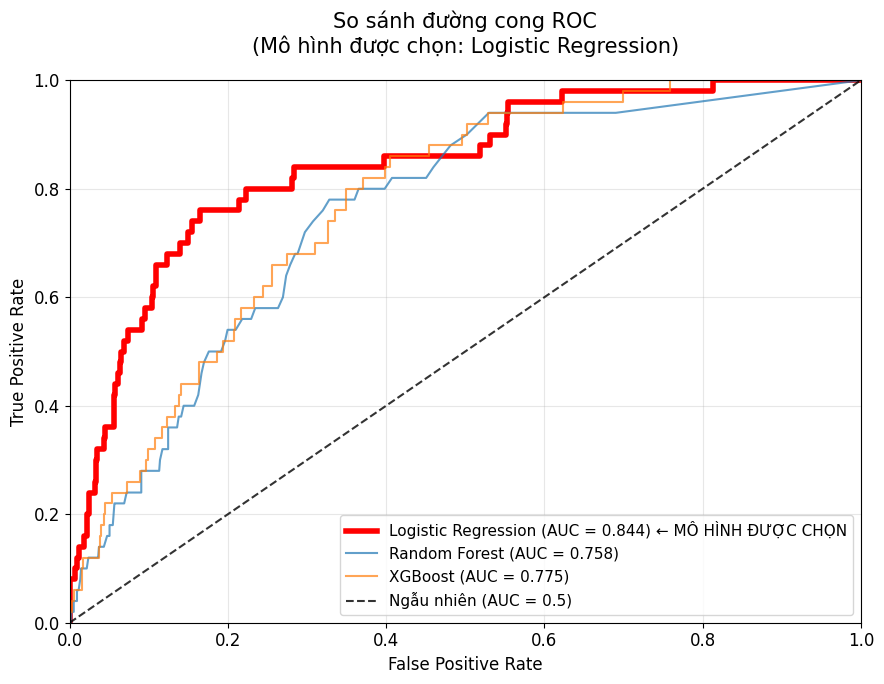

ROC-AUC của mô hình chính (Logistic + SMOTE): 0.8438


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import numpy as np

# Đảm bảo có tập test
if 'X_test' not in globals() or 'y_test' not in globals():
    raise ValueError("Không tìm thấy X_test hoặc y_test. Hãy chạy lại phần train/test split.")

plt.figure(figsize=(9, 7))

possible_names = ['model_lr', 'model_logistic_smote', 'final_model', 'best_model', 
                  'logreg', 'logreg_smote', 'clf', 'model', 'logistic_model', 'logreg_final']

logistic_model = None
model_name_used = None

for name in possible_names:
    if name in globals() and globals()[name] is not None:
        try:
            # Kiểm tra predict_proba
            globals()[name].predict_proba(X_test[:1])
            logistic_model = globals()[name]
            model_name_used = name
            break
        except:
            continue

if logistic_model is None:
    print("Không tự động tìm thấy mô hình Logistic")
    print("Các biến hiện có (có chứa 'model' hoặc 'log'):", 
          [name for name in globals().keys() if not name.startswith('_') and ('model' in name.lower() or 'log' in name.lower() or 'clf' in name)])
    print("\nVui lòng sửa tên biến ở dòng dưới đây:")
    logistic_model = model_lr 


# Vẽ ROC của mô hình chính
y_proba = logistic_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, 
         color='red', linewidth=4,
         label=f'Logistic Regression (AUC = {roc_auc:.3f}) ← MÔ HÌNH ĐƯỢC CHỌN')

for name, model in [('Random Forest', model_rf if 'model_rf' in globals() else None),
                    ('XGBoost', model_xgb if 'model_xgb' in globals() else None)]:
    if model is not None:
        try:
            proba = model.predict_proba(X_test)[:, 1]
            fpr2, tpr2, _ = roc_curve(y_test, proba)
            auc2 = auc(fpr2, tpr2)
            plt.plot(fpr2, tpr2, label=f'{name} (AUC = {auc2:.3f})', alpha=0.7)
        except:
            pass

# Đường chéo ngẫu nhiên
plt.plot([0, 1], [0, 1], 'k--', label='Ngẫu nhiên (AUC = 0.5)', alpha=0.8)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('So sánh đường cong ROC\n(Mô hình được chọn: Logistic Regression)', fontsize=15, pad=20)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# In kết quả AUC để chắc chắn
print(f"ROC-AUC của mô hình chính (Logistic + SMOTE): {roc_auc:.4f}")

## 4.3.5 Precision-Recall curve cho các model

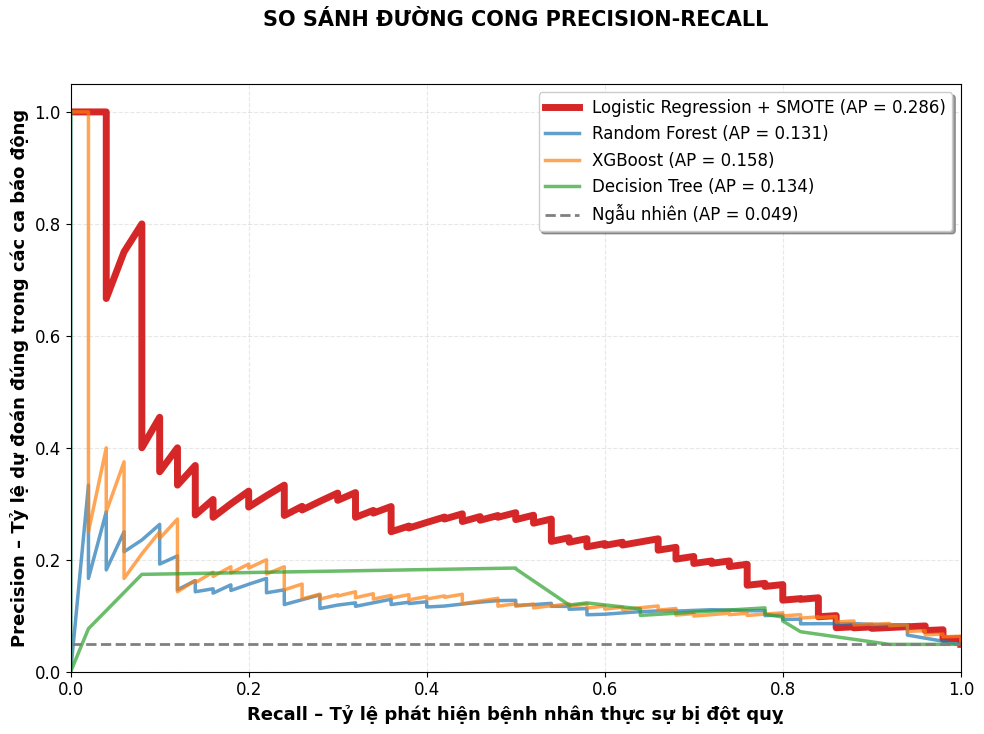

In [ ]:


from sklearn.metrics import precision_recall_curve, average_precision_score, auc
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 7.5))
plt.rcParams['font.size'] = 12

y_proba_lr = model_lr.predict_proba(X_test)[:, 1]
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_proba_lr)
ap_lr = average_precision_score(y_test, y_proba_lr)        # Average Precision
auc_pr_lr = auc(recall_lr, precision_lr)                   # AUC của PR curve

plt.plot(recall_lr, precision_lr,
         color='#d62728', linewidth=5,
         label=f'Logistic Regression + SMOTE (AP = {ap_lr:.3f})')

other_models = {
    'Random Forest': model_rf if 'model_rf' in globals() else None,
    'XGBoost'      : model_xgb if 'model_xgb' in globals() else None,
    'Decision Tree': model_dt if 'model_dt' in globals() else None
}

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for (name, model), color in zip(other_models.items(), colors):
    if model is not None:
        try:
            proba = model.predict_proba(X_test)[:, 1]
            prec, rec, _ = precision_recall_curve(y_test, proba)
            ap = average_precision_score(y_test, proba)
            plt.plot(rec, prec, color=color, alpha=0.7, linewidth=2.5,
                     label=f'{name} (AP = {ap:.3f})')
        except:
            pass

baseline = y_test.mean()
plt.axhline(y=baseline, color='gray', linestyle='--', linewidth=2,
            label=f'Ngẫu nhiên (AP = {baseline:.3f})')

plt.xlabel('Recall – Tỷ lệ phát hiện bệnh nhân thực sự bị đột quỵ', fontsize=13, fontweight='bold')
plt.ylabel('Precision – Tỷ lệ dự đoán đúng trong các ca báo động', fontsize=13, fontweight='bold')
plt.title('SO SÁNH ĐƯỜNG CONG PRECISION-RECALL\n',
          fontsize=15, fontweight='bold', pad=25)

plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=12, loc='upper right', frameon=True, fancybox=True, shadow=True)

plt.tight_layout()
plt.show()